In [81]:
%cd /home/ytee/test/trade_bot/
%matplotlib inline
from src.pattern.range_market import MY_RANGE, my_cache
import mplfinance as mpf
import numpy as np
import pandas as pd
from src.pattern.correlation import CORR3
import matplotlib.pyplot as plt

cr = CORR3(simulation=True)
mr = MY_RANGE()


/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


In [86]:
df =pd.read_csv('AUDUSD_1h.csv').dropna()
# df.columns = ['ccy', 'tf', 'sidx', 'eidx', 'emptiness', 'b1', 'b2' ]
df = df[df.tf=='1D']
df['g'] = df[['idx_start', 'idx_end']].apply(tuple, axis=1)
df['didx'] = df.idx_end -df.idx_start
df['bdiff'] = df.upper - df.lower
mr2 = mr.get_file('AUDUSD', '1D').reset_index()
# mr2 = mr2[mr2.index>50].copy()
mr2['Close2'] = mr2.Close.shift(50)
mr2.dropna(inplace=True)



In [87]:
def get_corr_by_columns(col):
# choose how many bins you want
    n_bins = 20
    edges = np.linspace(df[col].min(), df[col].max(), n_bins + 1)

    bins = pd.cut(df[col], bins=edges, include_lowest=True)
    g = df.groupby(bins, observed=True)['bdiff'].mean().reset_index(name='bdiff_mean')

    # use bin midpoints so the x-axis is numeric
    g[f'{col}_mid'] = g[col].apply(lambda interval: interval.mid)

    fig, ax = plt.subplots()
    ax.plot(g[f'{col}_mid'], g['bdiff_mean'], marker='o')
    ax.set_xlabel(f'{col} (binned)')
    ax.set_ylabel('mean bdiff')
    ax.set_title(f'Mean bdiff vs binned {col}')
    plt.show()

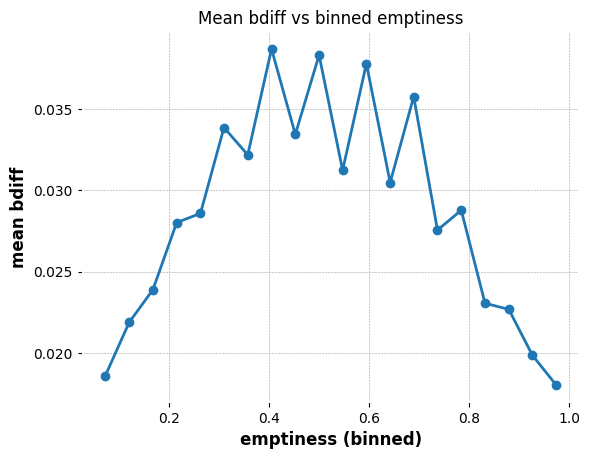

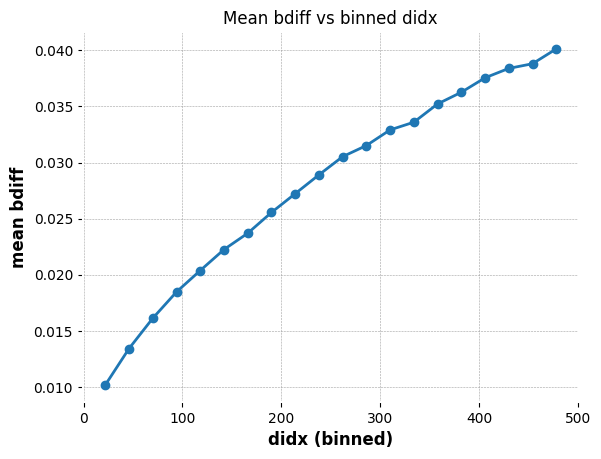

In [88]:
get_corr_by_columns('emptiness')
get_corr_by_columns('didx')

In [90]:
mr2['rangecount'] = mr2.index.map(df2.groupby('idx_end').idx_start.count()).fillna(0)
mr2['bdiff'] = mr2.index.map(df2.groupby('idx_end').bdiff.max()).fillna(0)
mr2['cdiff'] = mr2.Close2 - mr2.Close
mr2['profit'] = mr2['Close'].diff().shift(-1)

s = mr2["bdiff"].copy()
th = 0.003          # threshold that defines "trend"
K  = 3              # number of volatility-of-range states (excluding TREND)

# 1) Define TREND vs RANGE
trend_mask = s <= th
bull_mask =  mr2.cdiff > th
bear_mask =  mr2.cdiff < -th

# 2) Discretize only the RANGE part on log-scale
z = np.log(s[~trend_mask])                    # positive by construction
range_states = pd.qcut(
    z, q=K, labels=range(1, K+1), duplicates="drop"
)                                            # states 1..K (equal-frequency in log-space)

# 3) Build the full state series (0 = TREND)
mr2['state'] = 0
# states.loc[trend_mask]  = 0
mr2.loc[~trend_mask, 'state'] = range_states.astype("Int64")

mr2['next_state'] = mr2['state'].shift(-1)

mr2['direction'] = 0
mr2.loc[bull_mask, 'direction'] = 1
mr2.loc[bear_mask, 'direction'] = -1
mr2['next_direction'] = mr2['direction'].shift(-1)
mr2[['state', 'direction']] = mr2[['state', 'direction']].astype("int")

In [ ]:
mr2.to_csv('test.csv')

In [60]:
mr3 = mr2.dropna().copy()
mr3['pair'] =mr3[["state", 'direction']].apply(lambda x: '%s_%s' % (x['state'], x['direction']) , axis=1)


mr3.groupby(["state", 'direction']).profit.mean()


# by consecutive sequence
mr3["groupref"] = (mr3['pair'] != mr3['pair'].shift()).cumsum()
mr4 = mr3.groupby(["groupref", "pair"], as_index=False).profit.sum()
mr4.groupby('pair').profit.mean().to_csv('test.csv')
# mr3.groupby(["state", 'direction']).profit.mean().to_csv('test2.csv')
# mr3['next_pair'] = mr3['pair'].shift(1)


# joint = pd.crosstab(

#     [mr3["state"].astype(str), mr3["direction"].astype(str)],
#     [mr3["next_state"].astype(str), mr3["next_direction"].astype(str)],
#     normalize='index', dropna=True
# )
# joint.to_csv()

In [61]:
mr3 = mr2.dropna().copy()
mr3.groupby(["state"]).profit.mean()

mr3["groupref"] = (mr3['state'] != mr3['state'].shift()).cumsum()
mr4 = mr3.groupby(["groupref", "state"], as_index=False).profit.sum()
mr4.groupby('state').profit.mean()#.to_csv('test2.csv')


state
0    0.205390
1   -0.010862
2   -0.003281
3    0.010183
Name: profit, dtype: float64

In [66]:
mr3 = mr2.dropna().copy()
mr3.groupby(["direction"]).profit.mean()

mr3["groupref"] = (mr3['direction'] != mr3['direction'].shift()).cumsum()
mr4 = mr3.groupby(["groupref", "direction"], as_index=False).profit.sum()
mr4.groupby('direction').profit.mean()#.to_csv('test2.csv')

print(mr4.groupby('direction').profit.sum())

direction
-1    0.05061
 0   -0.11456
 1    0.07914
Name: profit, dtype: float64


In [35]:
mr3.direction.value_counts()

direction
 1    2369
-1    2131
 0     410
Name: count, dtype: int64

In [26]:
mr3 = mr2.dropna()
joint = pd.crosstab(
    [mr3["state"].astype(str), mr3["direction"].astype(str)],
    [mr3["next_state"].astype(str), mr3["next_direction"].astype(str)],
    normalize='index', dropna=True
)
joint.to_csv('joint.csv')

In [ ]:
mr3 = mr2.dropna()
joint = pd.crosstab(
    [mr3["direction"].astype(str), mr3["state"].astype(str), ],
    [ mr3["next_direction"].astype(str), mr3["next_state"].astype(str)],
    normalize='index', dropna=True
)
joint.to_csv('joint2.csv')

In [ ]:
mr3 = mr2.dropna()
joint = pd.crosstab(
    [mr3["direction"].astype(str) ],
    [ mr3["next_direction"].astype(str)],
    normalize='index', dropna=True
)
joint.to_csv('joint3.csv')

In [ ]:
counts =pd.crosstab(mr2['state'], mr2['next_state'], dropna=True)
transition_matrix = counts.div(counts.sum(axis=1), axis=0)
print(transition_matrix)

next_state       0.0       1.0       2.0       3.0
state                                             
0           0.923353  0.063473  0.010778  0.002395
1           0.043287  0.878210  0.066764  0.011739
2           0.002939  0.069067  0.882439  0.045555
3           0.000740  0.014804  0.044412  0.940044


In [ ]:
xx = mr2[(mr2.bdiff>0.001)].bdiff
xx2 = mr2[(mr2.bdiff<=0.001)].bdiff
print(len(xx), len(xx2))
# xx  = mr2.bdiff.clip(lower=1e-3)

# # xx.plot(kind='hist', bins=50)
np.log(xx).plot(kind='hist', bins=50)

4076 835


<Axes: ylabel='Frequency'>

In [ ]:
pd.qcut(mr2.bdiff, q=5).unique()

[(0.0208, 0.0587], (0.0143, 0.0208], (0.00948, 0.0143], (-0.001, 0.0023], (0.0023, 0.00948]]
Categories (5, interval[float64, right]): [(-0.001, 0.0023] < (0.0023, 0.00948] < (0.00948, 0.0143] < (0.0143, 0.0208] < (0.0208, 0.0587]]

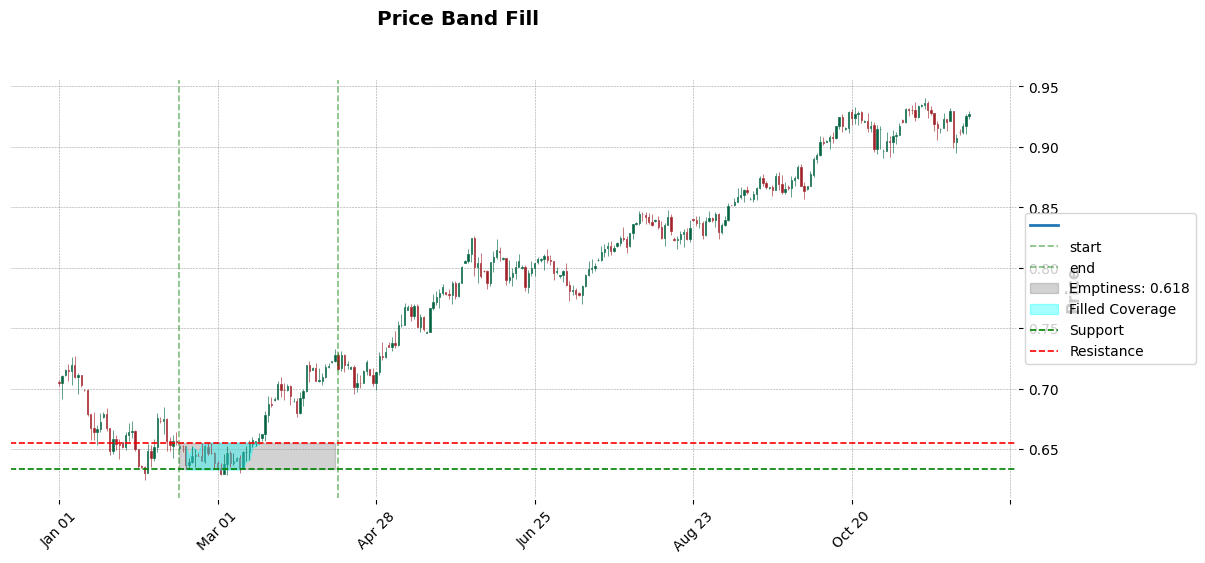

In [15]:
%matplotlib inline    
eidx= 88
mr.view_band('AUDUSD', '1D', eidx-50, eidx, threshold=0.6, tolerance=0.05)

In [100]:
mr3 = mr2.dropna().copy()
fast, slow = 10, 20
ema_f = mr3['Close'].ewm(span=fast, adjust=False).mean()
ema_s = mr3['Close'].ewm(span=slow, adjust=False).mean()
sig = ema_f - ema_s

dead = mr3['Close'].pct_change().rolling(50).std().fillna(0) * 0.2  # volatility-scaled band
mr3['dir_B'] = 0
mr3.loc[sig >  dead, 'dir_B'] = 1
mr3.loc[sig < -dead, 'dir_B'] = -1


print(mr3.groupby(["dir_B"]).profit.mean())

mr3["groupref"] = (mr3['dir_B'] != mr3['dir_B'].shift()).cumsum()
mr4 = mr3.groupby(["groupref", "dir_B"], as_index=False).profit.sum()
# mr4.groupby('dir_B').profit.mean()#.to_csv('test2.csv')

print(mr4.groupby('dir_B').profit.mean())


dir_B
-1   -0.000014
 0   -0.000014
 1    0.000028
Name: profit, dtype: float64
dir_B
-1   -0.000249
 0   -0.000069
 1    0.000549
Name: profit, dtype: float64


In [99]:
mr3 = mr2.dropna().copy()
W = 300
up = mr3['Close'] >= mr3['Close'].rolling(W).max().shift(1)
dn = mr3['Close'] <= mr3['Close'].rolling(W).min().shift(1)

mr3['dir_C'] = 0
mr3.loc[up, 'dir_C'] = 1
mr3.loc[dn, 'dir_C'] = -1

print(mr3.groupby(["dir_C"]).profit.mean())

mr3["groupref"] = (mr3['dir_C'] != mr3['dir_C'].shift()).cumsum()
mr4 = mr3.groupby(["groupref", "dir_C"], as_index=False).profit.sum()
# mr4.groupby('dir_C').profit.mean()#.to_csv('test2.csv')

print(mr4.groupby('dir_C').profit.mean())

dir_C
-1   -0.000322
 0    0.000012
 1    0.000130
Name: profit, dtype: float64
dir_C
-1   -0.000665
 0    0.000477
 1    0.000257
Name: profit, dtype: float64


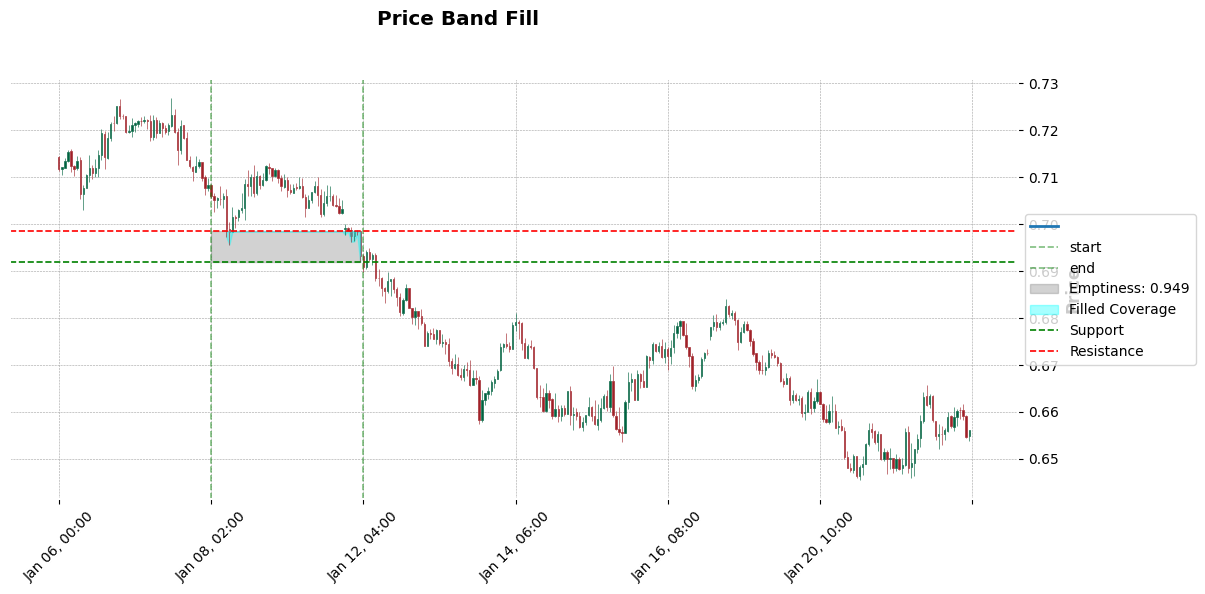

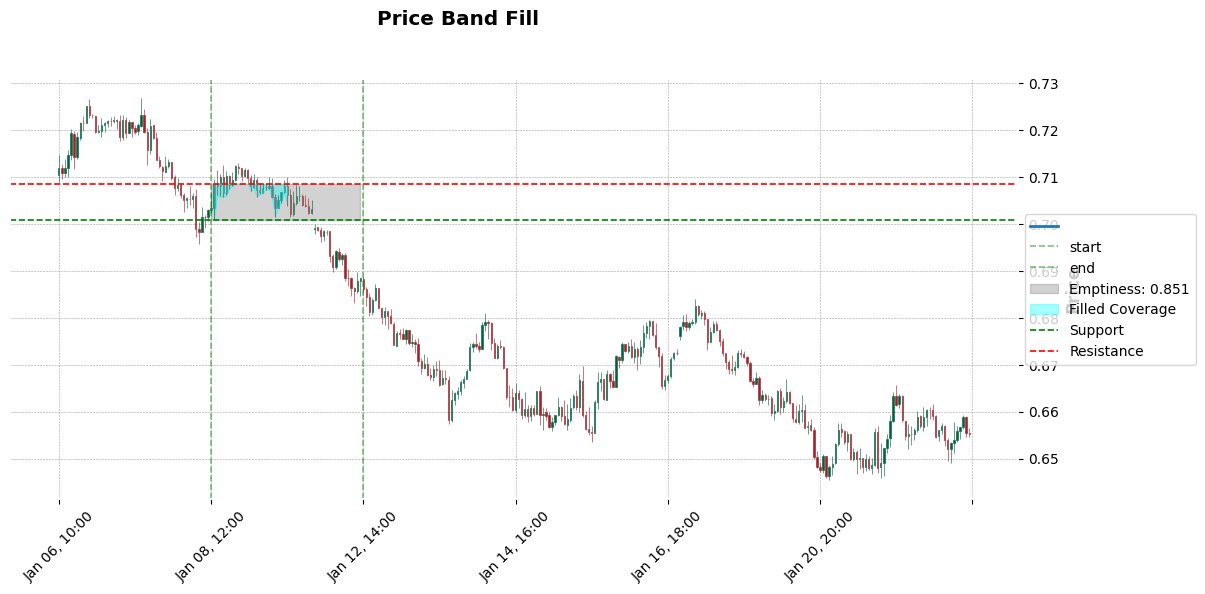

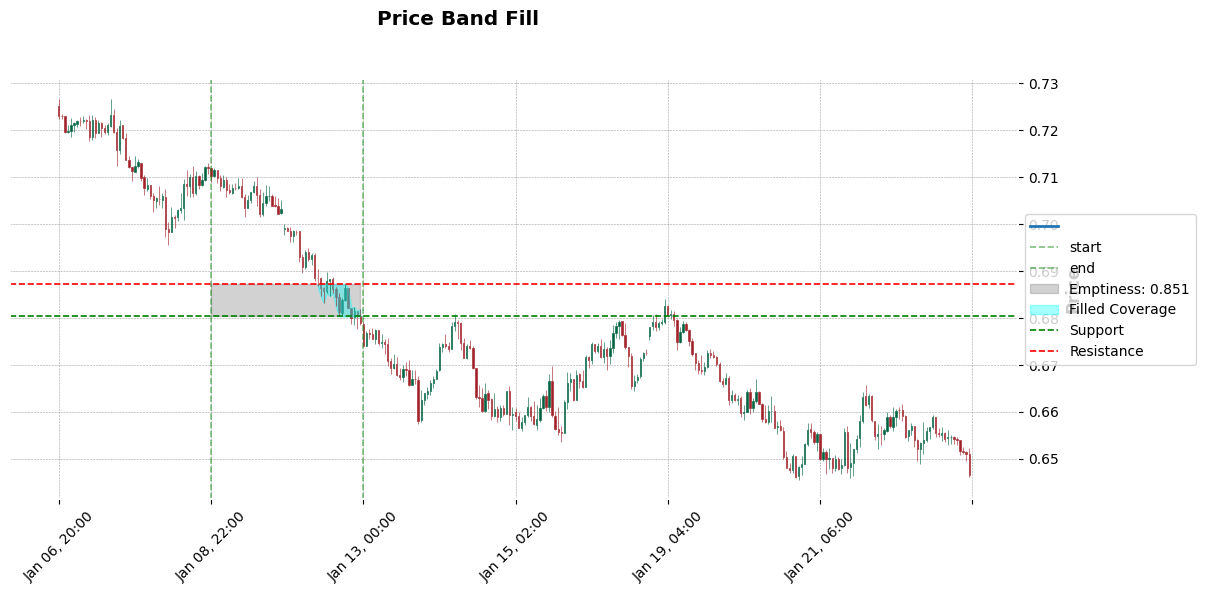

In [8]:

for eidx in range(150, 180, 10):

    mr.view_band('AUDUSD', '1h', eidx-50, eidx, threshold=0.9, tolerance=0.05)

In [5]:
import matplotlib
matplotlib.use('TkAgg')
%matplotlib inline